# Concentration GUI example

Notebook version of `qal.examples.concentration_rcs.concentration_gui_example`. Set `IMAGE_PATH` to one TIFF, BMP, PNG, or JPEG and run the cells in order.

**Workflow**

1. Run the import cell.
2. Set `IMAGE_PATH` and the GUI options. Turn on `SAVE_RESULTS` to write plots and tables next to the image.
3. Load the image, then open the well-selection GUI.
4. In **Cursor/VS Code** a native Matplotlib window opens. Click the first `ANCHOR_COUNT` wells in row-major order, then press **Enter** in that window.
5. Run the analysis cell. If `SAVE_RESULTS` is True, output goes in `<image_stem>_results` beside the image.


## Imports


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from qal import WellAnalyzer, WellPlotter, select_concentration_grid
from qal.data import get_concentration_target_preset
from qal.rta.roi_extraction.concentration_grid import complete_concentration_grid
from qal.util import describe_stored_values, load_grayscale_image


## Configuration

Set `IMAGE_PATH` to the file you want to process. If `SAVE_RESULTS` is True, plots and tables are written to `<image_name>_results` in the same folder as the image.


In [2]:
IMAGE_PATH = Path("../../data/concentration_targets/bitmap_sample.BMP")
SAVE_RESULTS = True

# Product preset: "icg", "q800", "q700", or "custom"
TARGET_TAG = "icg"

CUSTOM_WELL_IDS = [
    "1000 nM",
    "300 nM",
    "100 nM",
    "60 nM",
    "30 nM",
    "10 nM",
    "3 nM",
    "1 nM",
    "Control",
]

# "automatic_refinement", "manual_live_preview", or "manual_coordinates"
MODE = "manual_live_preview"

# Exact signal count, or None in manual_coordinates to accept up to nine regions.
ANCHOR_COUNT = 3

# None estimates diameter as 60% of target grid spacing.
MANUAL_ROI_DIAMETER = None
REGION_OF_WELL_TO_ANALYZE = 0.5


## Load the image


Loaded: /Users/eammon/Documents/GitHub/quel-qal/qal/data/concentration_targets/bitmap_sample.BMP
uint8, stored values 0–213
Target: ICG-equivalent concentration sensitivity target (icg)
Results folder: /Users/eammon/Documents/GitHub/quel-qal/qal/data/concentration_targets/bitmap_sample_results


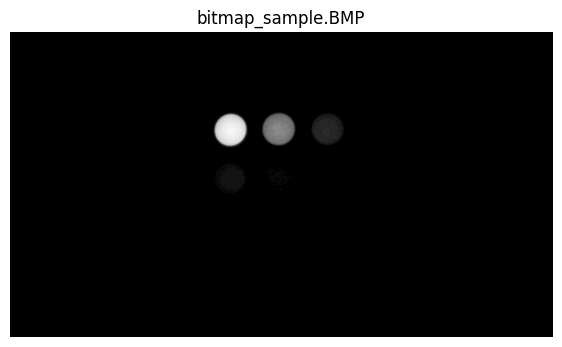

In [3]:
image_path = Path(IMAGE_PATH).expanduser().resolve()
if not image_path.is_file():
    raise FileNotFoundError(f"IMAGE_PATH is not a file: {image_path}")

image = load_grayscale_image(image_path)
print(f"Loaded: {image_path}")
print(describe_stored_values(image).summary())

target = get_concentration_target_preset(
    TARGET_TAG,
    custom_well_ids=(CUSTOM_WELL_IDS if TARGET_TAG == "custom" else None),
)
well_ids = target["well_ids"]
print(f"Target: {target['display_name']} ({target['tag']})")

results_dir = None
if SAVE_RESULTS:
    results_dir = image_path.parent / f"{image_path.stem}_results"
    results_dir.mkdir(parents=True, exist_ok=True)
    print(f"Results folder: {results_dir}")

fig, ax = plt.subplots(figsize=(7, 6))
ax.imshow(image, cmap="gray")
ax.set_title(image_path.name)
ax.axis("off")
plt.show()


## Select wells

In Cursor/VS Code, `select_concentration_grid` opens a native Matplotlib window and returns the completed well table after you press Enter. JupyterLab may instead return a session; click Confirm, then run the next cell.


In [4]:
plt.close("all")
session = select_concentration_grid(
    image,
    well_ids,
    mode=MODE,
    anchor_count=ANCHOR_COUNT,
    manual_roi_diameter=MANUAL_ROI_DIAMETER,
    verbose=False,
)
wells = session if isinstance(session, pd.DataFrame) else None


Opening a native Matplotlib window. Click the wells, then press Enter. VS Code/Cursor cannot load ipympl's jupyter-matplotlib widget.


## Analyze

Run this after the native window closes, or after clicking Confirm in JupyterLab. If `SAVE_RESULTS` is on, this cell writes plots and CSVs into the results folder.


In [5]:
if not isinstance(wells, pd.DataFrame):
    if isinstance(session, pd.DataFrame):
        wells = session
    else:
        anchors = getattr(session, "result", None)
        if not isinstance(anchors, pd.DataFrame):
            raise RuntimeError("No confirmed selection yet.")
        wells = complete_concentration_grid(
            image, anchors, well_ids=well_ids, mode=MODE
        )

analyzer = WellAnalyzer(image, wells)
stats = analyzer.get_stats(region_of_well_to_analyze=REGION_OF_WELL_TO_ANALYZE)
plotter = WellPlotter(stats, image=image)
plotter.visualize_roi()
if results_dir is not None:
    plt.savefig(results_dir / "roi.png", bbox_inches="tight")

if (wells["well"] == "Control").any():
    plotter.plot(
        graph_type="concentration",
        col_to_plot="mean intensity normalized",
        fluorophore_label=target.get("fluorophore_label", "ICG-eq"),
        trendline_lib="statsmodels",
        save_plot=(
            None if results_dir is None else results_dir / "concentration.png"
        ),
    )

if results_dir is not None:
    wells.to_csv(results_dir / "wells.csv", index=False)
    stats.to_csv(results_dir / "stats.csv", index=False)
    print(f"Saved results to {results_dir}")


Saved results to /Users/eammon/Documents/GitHub/quel-qal/qal/data/concentration_targets/bitmap_sample_results
